# Various Data Tests

In [3]:
import pandas as pd
import numpy as np
import random
import os
import torch
import faiss
import json
import re
import shutil
import random
from tqdm import tqdm
from torch import Tensor
from dotenv import load_dotenv
from huggingface_hub import login
from torch.utils.data import DataLoader
import torch.nn.functional as F
from beir.datasets.data_loader import GenericDataLoader
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, logging, AutoModel, AutoModelForCausalLM
logging.set_verbosity_error()

/work/mbouthil/.conda/envs/myuwenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Loading in datasets
data_dir = "/work/mbouthil/datasets/msmarco"
train_corpus, train_queries, train_qrels = GenericDataLoader(data_folder=data_dir).load(split='train')
test_corpus, test_queries, test_qrels = GenericDataLoader(data_folder=data_dir).load(split='dev')

 36%|███▌      | 3203841/8841823 [00:28<00:48, 116690.17it/s]

In [ ]:
test_q = [(q_id, query) for q_id, query in test_queries.items()]
train_q = [(q_id, query) for q_id, query in train_queries.items()]

# Query Cosine Similarity

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def query_tok(queries:list[str], max_length:int=32) -> dict:
    with torch.no_grad():
        inputs = tokenizer(
            queries, 
            padding=True,
            truncation=True,
            return_tensors="pt",
            max_length=max_length
        ).to(device)
    return inputs

In [ ]:
query_encoder = AutoModel.from_pretrained(
    "/work/mbouthil/MMATH-CM-Research-Project/RAG/model_weights/query_encoder_v01"
).to(device)

def encode_query(query:str) -> Tensor:

    queries = [query] if isinstance(query, str) else query
    embeddings = []

    with torch.no_grad():
        inputs = tokenizer(
            queries, 
            padding=True,
            truncation=True,
            return_tensors="pt",
            max_length=32
        ).to(device)

    # Mean Pooling
    out = query_encoder(**inputs)
    last_hidden_state = out.last_hidden_state
    mask = inputs['attention_mask'].unsqueeze(-1).float()
    emb = (last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1)

    emb = F.normalize(emb, p=2, dim=-1)
    embeddings.append(emb.cpu())

    return torch.cat(embeddings, 0)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 297.28it/s, Materializing param=pooler.dense.weight]                               


In [ ]:
def batch_splits(item:list, batch_size:int=100):

    for i in range(0, len(item), batch_size):
        yield item[i:i + batch_size]

train_batches = batch_splits(train_q)
test_batches = batch_splits(test_q)

In [ ]:
sim_q_ids = []

for train_batch in train_batches:

    train_ids, train_batch = zip(*train_batch)
    train_emb = encode_query(train_batch)
    
    for test_batch in test_batches:

        test_ids, test_batch = zip(*test_batch)
        test_emb = encode_query(test_batch)

        sim = torch.matmul(test_emb, train_emb.T).detach().cpu().numpy()
        indices = np.where(sim >= 0.7)

        q_test_ids = [test_ids[i] for i in set(indices[0])]
        q_train_ids = [train_ids[i] for i in set(indices[1])]
        sim_q_ids.extend(list(zip(q_train_ids, q_test_ids)))
        break
    break

# dir = "/work/mbouthil/MMATH-CM-Research-Project/RAG/test_results"
# path = os.path.join(dir, "sim_queries.jsonl")

# with open(path, "w") as f:
#     for train_id, test_id in sim_q_ids:
#         entry = {"train_id": train_id, "test_id": test_id}
#         f.write(json.dumps(entry) + "\n")

# Plotting query distributions

In [1]:
from collections import Counter
import spacy
nlp = spacy.load("en_core_web_sm")

def tokenize_corpus(corpus):
    tokens = []
    for doc in corpus:
        parsed = nlp(doc)
        for token in parsed:
            if not token.is_stop and token.is_alpha:
                tokens.append(token.lemma_.lower())
    return tokens

def relative_freq(tokens):
    counts = Counter(tokens)
    total = sum(counts.values())
    return {w:c/total for w,c in counts.items()}

In [2]:
train_tokens = tokenize_corpus(list(train_queries.values()))
test_tokens = tokenize_corpus(list(test_queries.values()))

train_dist = relative_freq(train_tokens)
test_dist = relative_freq(test_tokens)

vocab = set((train_dist) | (test_dist))

NameError: name 'train_queries' is not defined

In [ ]:
from scipy.spatial.distance import jensenshannon

vec_A = np.array([train_dist.get(w,0) for w in vocab])
vec_B = np.array([test_dist.get(w,0) for w in vocab])

js = jensenshannon(vec_A, vec_B)
print("JS divergence:", js)

JS divergence: 0.2983105904177286


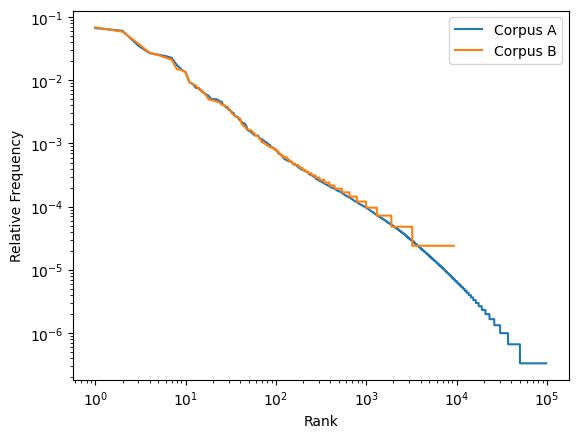

In [55]:
import matplotlib.pyplot as plt

def zipf_plot(freq_dict, label):
    
    freqs = sorted(freq_dict.values(), reverse=True)
    ranks = np.arange(1, len(freqs)+1)
    
    plt.loglog(ranks, freqs, label=label)

plt.figure()
zipf_plot(train_dist, "Corpus A")
zipf_plot(test_dist, "Corpus B")
plt.xlabel("Rank")
plt.ylabel("Relative Frequency")
plt.legend()
plt.show()


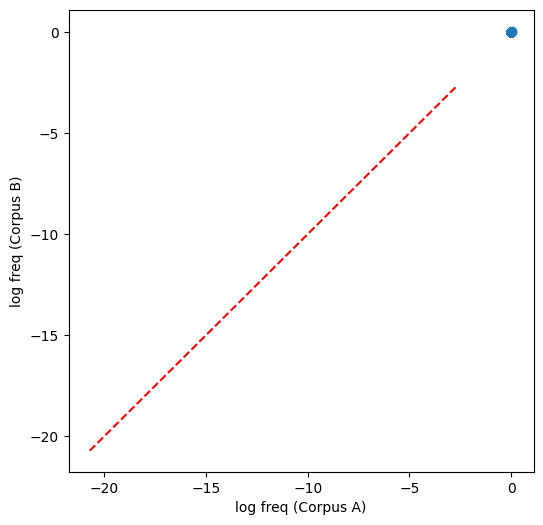

In [59]:
import numpy as np
import matplotlib.pyplot as plt

eps = 1e-9
x = [np.log(train_dist.get(w, eps)) for w in vocab]
y = [np.log(test_dist.get(w, eps)) for w in vocab]


plt.figure(figsize=(6,6))
plt.scatter(vec_A, vec_B, alpha=0.3)
plt.plot([min(x), max(x)], [min(x), max(x)], 'r--')
plt.xlabel("log freq (Corpus A)")
plt.ylabel("log freq (Corpus B)")
plt.show()

# Various Data Inspection

In [36]:
# Loading in datasets
data_dir = "/work/mbouthil/datasets/msmarco_synq_final"
synq_corpus, synq_queries, synq_qrels = GenericDataLoader(data_folder=data_dir).load(split='train')

100%|██████████| 8841823/8841823 [01:18<00:00, 113321.17it/s]


In [37]:
print(len(synq_queries))
print(len(train_queries))
print(len(train_queries)-len(synq_queries))

1005878
502939
-502939
